In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#load data
df = pd.read_csv('../data/raw/Reviews.csv')

In [18]:
print(df.head())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB
None


In [20]:
#basic eda
print(df.describe())

                  Id  HelpfulnessNumerator  HelpfulnessDenominator  \
count  568454.000000         568454.000000            568454.00000   
mean   284227.500000              1.743817                 2.22881   
std    164098.679298              7.636513                 8.28974   
min         1.000000              0.000000                 0.00000   
25%    142114.250000              0.000000                 0.00000   
50%    284227.500000              0.000000                 1.00000   
75%    426340.750000              2.000000                 2.00000   
max    568454.000000            866.000000               923.00000   

               Score          Time  
count  568454.000000  5.684540e+05  
mean        4.183199  1.296257e+09  
std         1.310436  4.804331e+07  
min         1.000000  9.393408e+08  
25%         4.000000  1.271290e+09  
50%         5.000000  1.311120e+09  
75%         5.000000  1.332720e+09  
max         5.000000  1.351210e+09  


In [21]:
#check for missing values
print(df.isnull().sum())

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [22]:
#check for duplicates
print(df.duplicated().sum())

0


In [23]:


#check for unique values in each column
print(df.nunique())

Id                        568454
ProductId                  74258
UserId                    256059
ProfileName               218415
HelpfulnessNumerator         231
HelpfulnessDenominator       234
Score                          5
Time                        3168
Summary                   295742
Text                      393579
dtype: int64


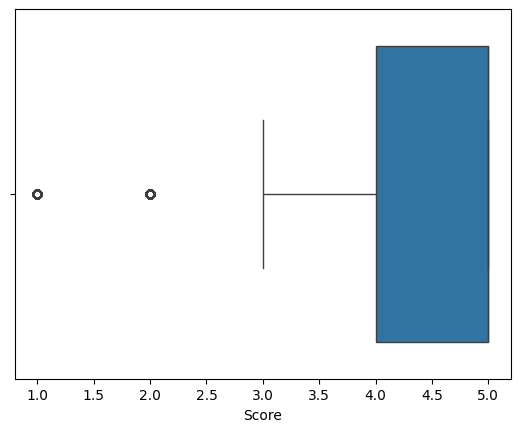

In [24]:
#check for outliers
sns.boxplot(x=df['Score'])
plt.show()

In [15]:
#check for correlation between numerical columns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

ValueError: could not convert string to float: 'B001E4KFG0'

In [25]:
# Check missing values
print(df.isnull().sum())

# Handle missing values
df['ProfileName'].fillna('Unknown', inplace=True)
df['Summary'].fillna('No Summary', inplace=True)

# Verify no missing values remain
print(df.isnull().sum())

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


C:\Users\techw\AppData\Local\Temp\ipykernel_2456\2315518911.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ProfileName'].fillna('Unknown', inplace=True)
C:\Users\techw\AppData\Local\Temp\ipykernel_2456\2315518911.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64


In [26]:
df['Time'] = pd.to_datetime(df['Time'], unit='s')
print(df['Time'].head())

0   2011-04-27
1   2012-09-07
2   2008-08-18
3   2011-06-13
4   2012-10-21
Name: Time, dtype: datetime64[ns]


In [27]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Check for duplicate reviews (same UserId, ProductId, and Text)
duplicates = df.duplicated(subset=['UserId', 'ProductId', 'Text']).sum()
print(f"Number of duplicate reviews: {duplicates}")

Number of duplicate rows: 0
Number of duplicate reviews: 1309


In [28]:
#with duplicate, just keep first one
df = df.drop_duplicates(subset=['UserId', 'ProductId', 'Text'], keep='first')

In [29]:
# Numeric columns
print(df.describe())

                  Id  HelpfulnessNumerator  HelpfulnessDenominator  \
count  567145.000000         567145.000000           567145.000000   
mean   284249.697605              1.741369                2.224438   
min         1.000000              0.000000                0.000000   
25%    142118.000000              0.000000                0.000000   
50%    284270.000000              0.000000                1.000000   
75%    426373.000000              2.000000                2.000000   
max    568454.000000            866.000000              923.000000   
std    164112.697226              7.639832                8.289417   

               Score                           Time  
count  567145.000000                         567145  
mean        4.184009  2011-01-29 08:49:50.422554880  
min         1.000000            1999-10-08 00:00:00  
25%         4.000000            2010-04-15 00:00:00  
50%         5.000000            2011-07-21 00:00:00  
75%         5.000000            2012-03-26 00

In [30]:
# Categorical columns
print(df[['ProductId', 'UserId', 'ProfileName']].describe())

         ProductId          UserId       ProfileName
count       567145          567145            567145
unique       74258          256059            218415
top     B007JFMH8M  A3OXHLG6DIBRW8  C. F. Hill "CFH"
freq           913             442               445


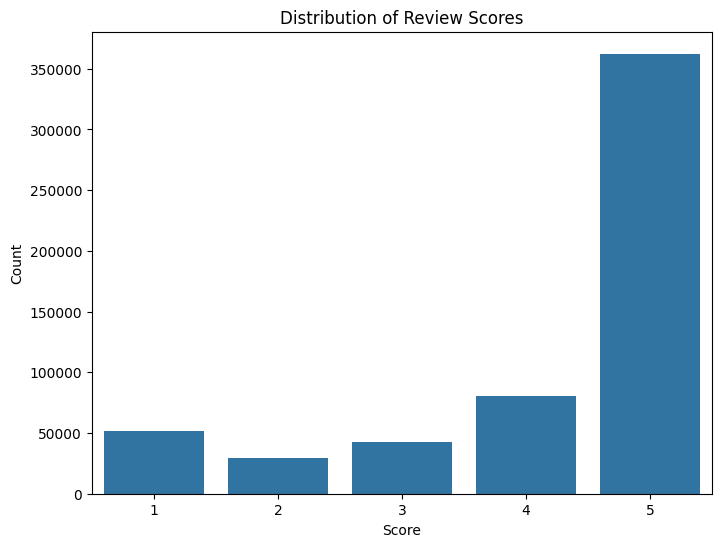

In [31]:
# Plot score distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Score', data=df)
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

In [32]:
# Check if HelpfulnessNumerator > HelpfulnessDenominator
invalid_helpfulness = df[df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']]
print(f"Rows with invalid helpfulness: {len(invalid_helpfulness)}")

Rows with invalid helpfulness: 2


In [33]:
df = df[df['HelpfulnessNumerator'] <= df['HelpfulnessDenominator']]

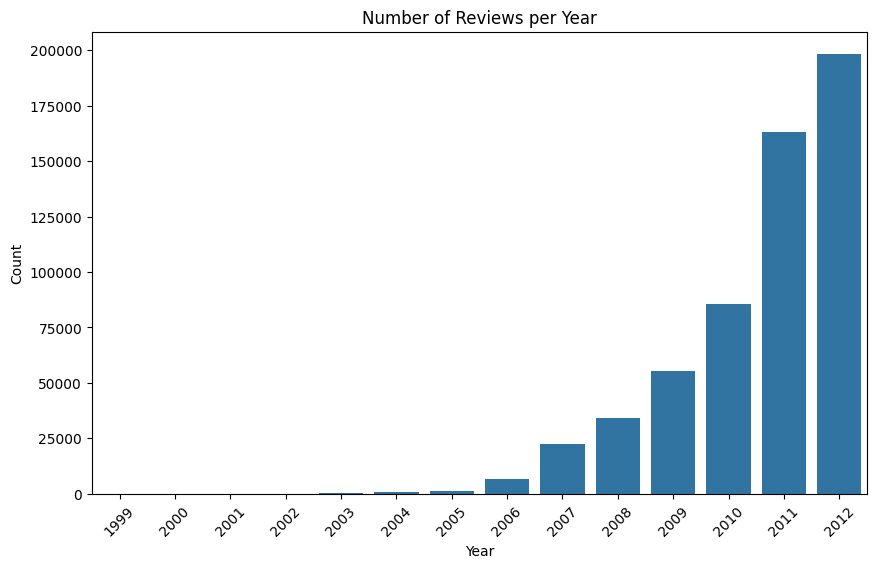

In [34]:
# Extract year and month
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

# Plot reviews per year
plt.figure(figsize=(10, 6))
sns.countplot(x='Year', data=df)
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Unique Products: 74258
Unique Users: 256059


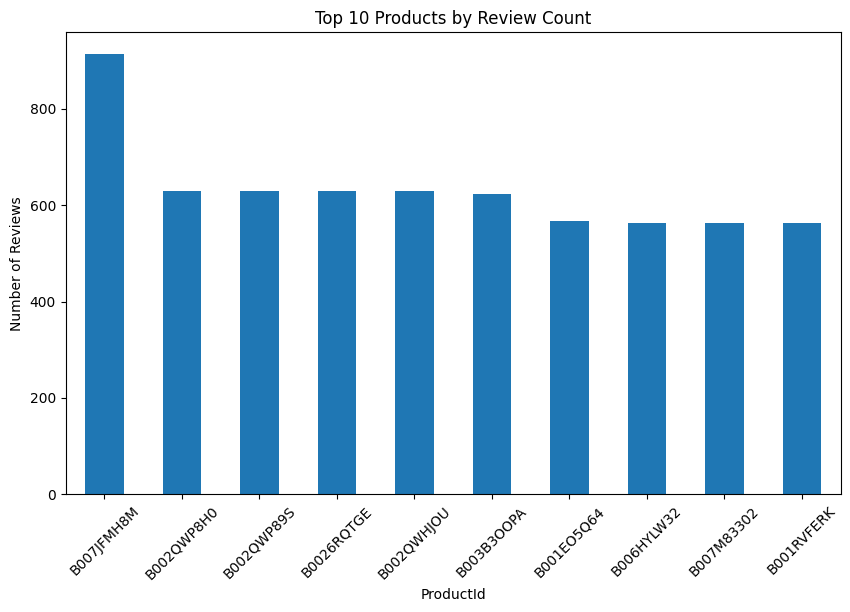

In [35]:
# Unique products and users
print(f"Unique Products: {df['ProductId'].nunique()}")
print(f"Unique Users: {df['UserId'].nunique()}")

# Top 10 products by review count
top_products = df['ProductId'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Review Count')
plt.xlabel('ProductId')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

       Text_WordCount  Summary_WordCount
count   567143.000000      567143.000000
mean        79.856631           4.109639
std         78.052169           2.594692
min          3.000000           1.000000
25%         33.000000           2.000000
50%         56.000000           4.000000
75%         98.000000           5.000000
max       3432.000000          42.000000


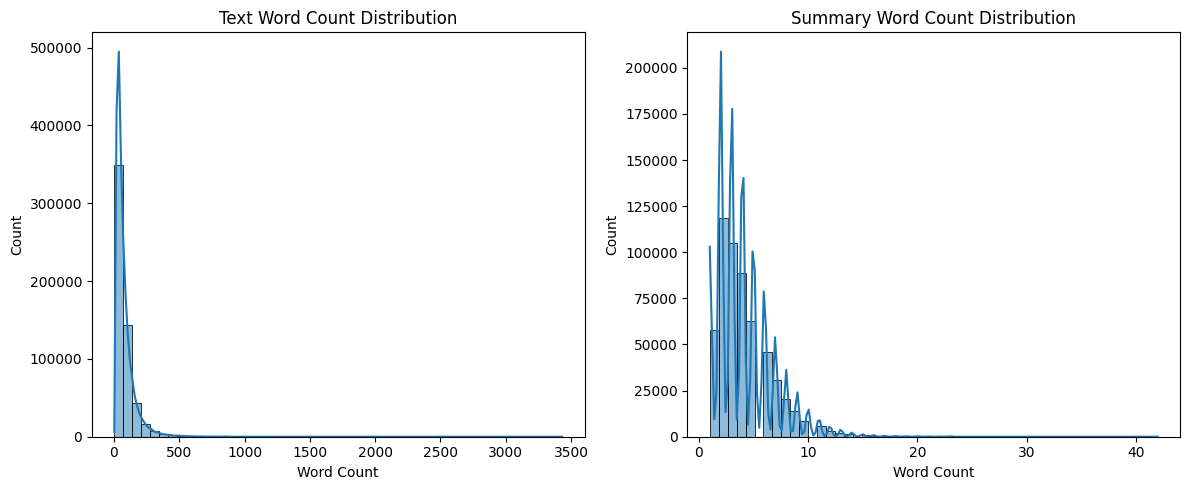

In [36]:
# Word count for Text and Summary
df['Text_WordCount'] = df['Text'].apply(lambda x: len(str(x).split()))
df['Summary_WordCount'] = df['Summary'].apply(lambda x: len(str(x).split()))

# Summary statistics for word counts
print(df[['Text_WordCount', 'Summary_WordCount']].describe())

# Plot word count distributions
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Text_WordCount'], bins=50, kde=True)
plt.title('Text Word Count Distribution')
plt.xlabel('Word Count')

plt.subplot(1, 2, 2)
sns.histplot(df['Summary_WordCount'], bins=50, kde=True)
plt.title('Summary Word Count Distribution')
plt.xlabel('Word Count')
plt.tight_layout()
plt.show()

In [37]:
# Correlation matrix
corr = df[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio', 'Text_WordCount']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

KeyError: "['HelpfulnessRatio'] not in index"

In [38]:
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'].replace(0, 1)

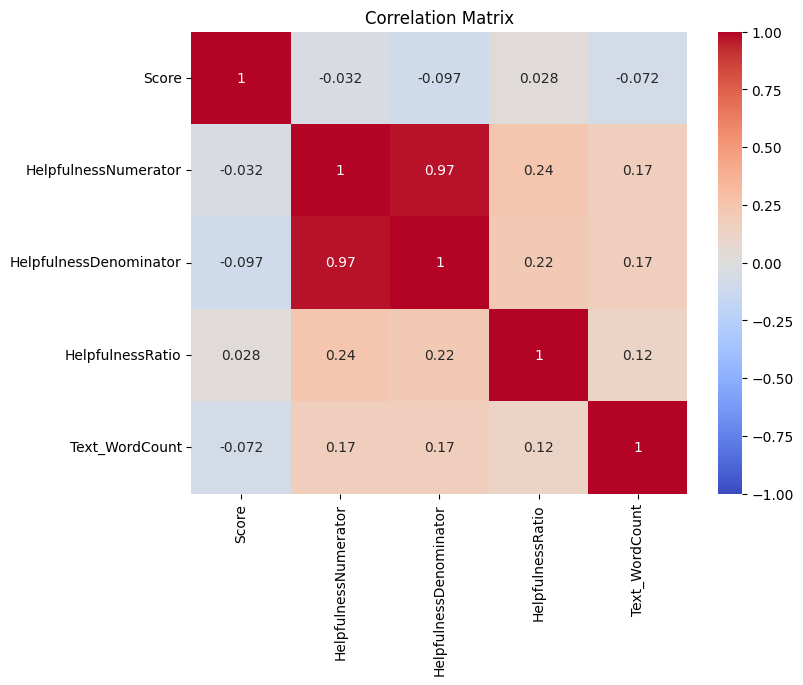

In [39]:
# Correlation matrix
corr = df[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio', 'Text_WordCount']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
#check for distribution of ratings
sns.histplot(df['Score'], bins=5, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#check for distribution of reviews
sns.histplot(df['Text'], bins=50, kde=True)
plt.title('Distribution of Reviews')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:

#check for distribution of helpfulness
sns.histplot(df['HelpfulnessNumerator'], bins=50, kde=True)
plt.title('Distribution of Helpfulness Numerator')
plt.xlabel('Helpfulness Numerator')
plt.ylabel('Frequency')
plt.show()

In [ ]:

#check for distribution of helpfulness denominator
sns.histplot(df['HelpfulnessDenominator'], bins=50, kde=True)
plt.title('Distribution of Helpfulness Denominator')
plt.xlabel('Helpfulness Denominator')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#check for distribution of time
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Distribution of Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#check for distribution of summary
sns.histplot(df['Summary'], bins=50, kde=True)
plt.title('Distribution of Summary')
plt.xlabel('Summary Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#check for distribution of product id
sns.histplot(df['ProductId'], bins=50, kde=True)
plt.title('Distribution of Product Id')
plt.xlabel('Product Id')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#check for distribution of user id
sns.histplot(df['UserId'], bins=50, kde=True)
plt.title('Distribution of User Id')
plt.xlabel('User Id')
plt.ylabel('Frequency')
plt.show()